In [129]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from skimage.io import imread
import pandas as pd
import os
import glob
from collections import defaultdict
import re
import scanpy as sc
from utils import generate_anndata_from_ark_analysis

This notebook contains:
- cell type proportion between resp and non-resp
- average protein count in cells for every leap, to show difference between resp and non resp
- carboplatin across cell types

In [130]:
cell_table_path='../../segmentation/cell_table_Denoised/cell_table_size_normalized_cell_labels.csv'
adata = generate_anndata_from_ark_analysis(cell_table_path=cell_table_path)
core = adata[adata.obs['SAMPLE_TYPE_(CORE/RESECTION)']=='CORE'].copy()

/home/giuseppe/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/giuseppe/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/giuseppe/devices/Delta_Tissue/IMC/IMC_analysis/results_analysis/utils.py:41: ImplicitModificationWarning: Trying to modify attribute `.X` of view, initializing view as actual.
  adata.X[adata.X>1]=1


In [18]:

biosamples_path = '../../'+'IMC_data/ExtraDocs/processed_response.csv'
biosamples =pd.read_csv(biosamples_path)


In [131]:
tb = pd.read_csv(cell_table_path)

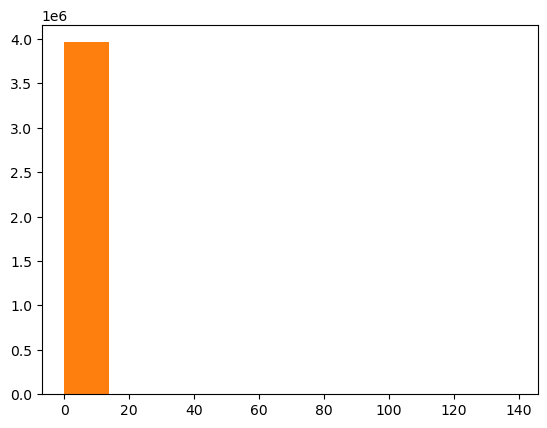

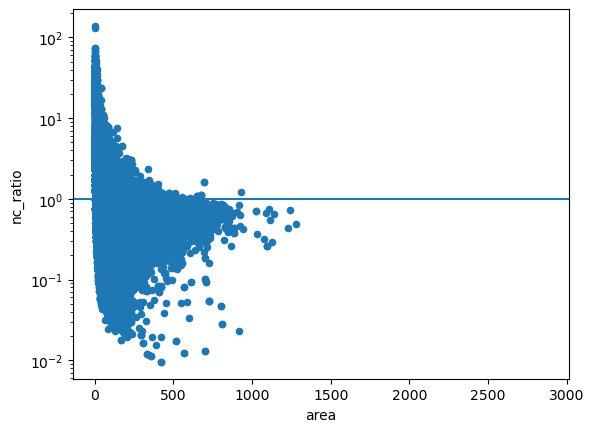

In [137]:
plt.hist(tb['nc_ratio'])
list(tb.columns)
plt.hist(tb['nc_ratio_nuclear'])
tb[['area','nc_ratio']].plot(x ='area',y = 'nc_ratio',kind = 'scatter')
plt.semilogy()
plt.axhline(1)

In [143]:
print('fraction of problematic cases')
(tb['nc_ratio']>1).value_counts(normalize=True)

fraction of problematic cases


nc_ratio
False    0.975826
True     0.024174
Name: proportion, dtype: float64

Patients split between responders and non responders

In [6]:

a = core.obs[['Leap_ID','SAMPLE_TYPE_(CORE/RESECTION)','Response']]
a.drop_duplicates().Response.value_counts()

Response
Non-Responder    31
pCR              25
Name: count, dtype: int64

In [7]:
a = adata.obs[['Leap_ID','SAMPLE_TYPE_(CORE/RESECTION)','Response']]
a.drop_duplicates().Response.value_counts()

Response
Non-Responder    64
pCR              25
Name: count, dtype: int64

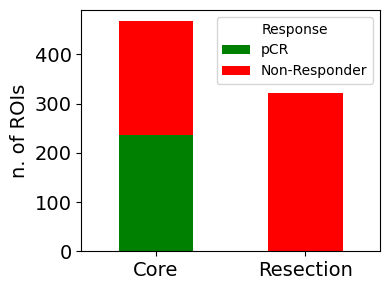

In [8]:
c = pd.DataFrame()
c['Core'] = core.obs[['acquisition_ID','Leap_ID','SAMPLE_TYPE_(CORE/RESECTION)','Response']].drop_duplicates()['Response'].value_counts()
res = adata[adata.obs['SAMPLE_TYPE_(CORE/RESECTION)']=='RESECTION'].copy()
c['Resection'] = res.obs[['acquisition_ID','Leap_ID','SAMPLE_TYPE_(CORE/RESECTION)','Response']].drop_duplicates()['Response'].value_counts()
c.fillna(0,inplace = True)
c.T.plot(kind = 'bar',stacked = True,color = ['green','red'],rot = 0,fontsize = 14,figsize = (4,3))
plt.ylabel('n. of ROIs',fontsize = 14)
plt.tight_layout()
#plt.savefig('../figures/ROIs_distribution.png')

## Inspecting the cell annotation

<Axes: xlabel='Pixie'>

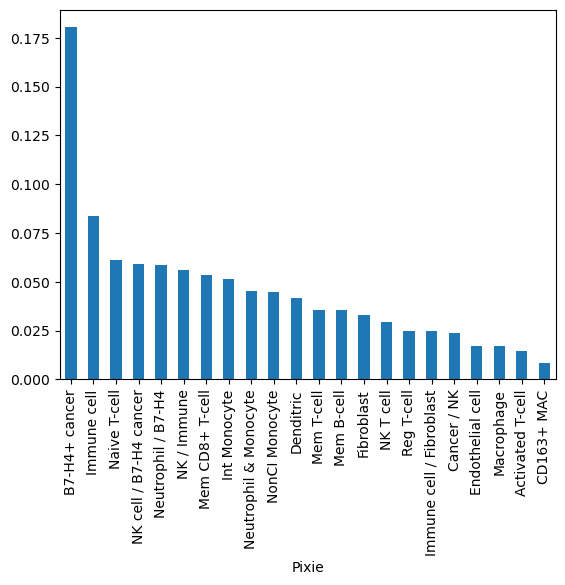

In [16]:
adata.obs.Pixie.value_counts(normalize=True).plot(kind = 'bar')


In [21]:
core = adata[adata.obs['SAMPLE_TYPE_(CORE/RESECTION)']=='CORE'].copy()

In [22]:
biosamples =pd.read_csv('../../IMC_data/ExtraDocs/processed_response.csv')
a = pd.DataFrame(core.obs[['Pixie','acquisition_ID']].value_counts()).reset_index(level = [0])
cell_type_per_fov = sc.AnnData(pd.pivot(a,columns = 'Pixie',values='count').fillna(0))
#rows are acquisitions, columns are cell type labels, value is the number of cells
cell_type_per_fov.obs['Leap_ID'] = cell_type_per_fov.obs.index.str.split('_',n = 1).str[0].str.upper()
cell_type_per_fov.obs = cell_type_per_fov.obs.merge(biosamples,left_on='Leap_ID',right_on= 'LEAP_ID').drop(['LEAP_ID'],axis = 1)
sc.pp.normalize_total(cell_type_per_fov,1)# we look at frequency of cells per image

Statistically significant differentially cell types are:
Neutrophil / B7-H4,Immune cell / Fibroblast,Immune cell,Naive T-cell,Endothelial cell,Macrophage,NK / Immune,Reg T-cell


/home/giuseppe/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/tmp/ipykernel_200202/1199017482.py:3: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


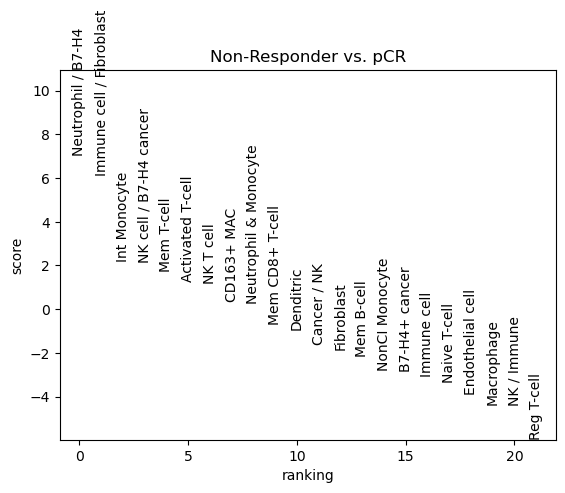

In [23]:
sc.tl.rank_genes_groups(cell_type_per_fov, groupby='Response',  method='wilcoxon',groups=['Non-Responder'],reference='pCR', key_added = "wilcoxon")
sc.pl.rank_genes_groups(cell_type_per_fov,n_genes=len(cell_type_per_fov.var.index), sharey=False, key = "wilcoxon",fontsize=10,show = False)
plt.tight_layout()
#plt.savefig('figures/diff_expr_marker/rank_genes.png')
print('Statistically significant differentially cell types are:')
print(*cell_type_per_fov.uns['wilcoxon']['names']['Non-Responder'][cell_type_per_fov.uns['wilcoxon']['pvals_adj']['Non-Responder']<0.01],sep = ',')

In [25]:
print('Statistically significant different cell type:')
stat_sign_diff_ct = cell_type_per_fov.uns['wilcoxon']['names']['Non-Responder'][cell_type_per_fov.uns['wilcoxon']['pvals_adj']['Non-Responder']<0.01]
print(*stat_sign_diff_ct,sep = ',')
sc.get.rank_genes_groups_df(cell_type_per_fov, group='Non-Responder', key='wilcoxon')

Statistically significant different cell type:
Neutrophil / B7-H4,Immune cell / Fibroblast,Immune cell,Naive T-cell,Endothelial cell,Macrophage,NK / Immune,Reg T-cell


,names,scores,logfoldchanges,pvals,pvals_adj
0,Neutrophil / B7-H4,7.036829,3.092127,1.966647e-12,4.326623e-11
1,Immune cell / Fibroblast,6.092069,1.549272,1.114605e-09,1.226066e-08
2,Int Monocyte,2.184777,-0.041763,2.890516e-02,5.299280e-02
3,NK cell / B7-H4 cancer,2.105905,0.823631,3.521263e-02,5.959061e-02
4,Mem T-cell,1.697138,-0.054983,8.967064e-02,1.315169e-01
5,Activated T-cell,1.265395,2.561642,2.057299e-01,2.662387e-01
6,NK T cell,1.175205,-0.824236,2.399126e-01,2.932265e-01
7,CD163+ MAC,0.329208,0.877153,7.419982e-01,7.773315e-01
8,Neutrophil & Monocyte,0.236276,0.204342,8.132188e-01,8.132188e-01
9,Mem CD8+ T-cell,-0.722201,-0.044005,4.701710e-01,5.171881e-01


/home/giuseppe/anaconda3/lib/python3.9/site-packages/scanpy/tools/_dendrogram.py:135: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = rep_df.groupby(level=0).mean()


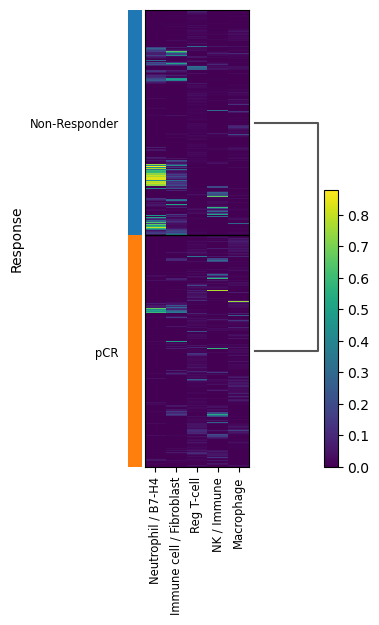

In [26]:
genes_high_pvalue = sc.get.rank_genes_groups_df(cell_type_per_fov, group='Non-Responder', key='wilcoxon').sort_values('pvals')['names'].iloc[:5].values
sc.pl.rank_genes_groups_heatmap(cell_type_per_fov,var_names=genes_high_pvalue, key="wilcoxon", groupby="Response", show_gene_labels=True)


/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Categorica

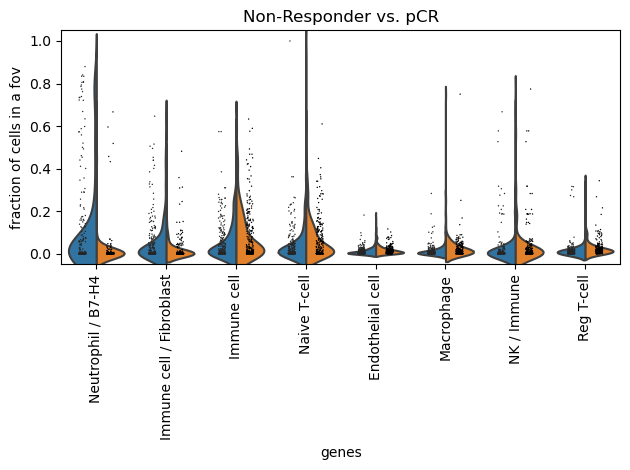

In [27]:
sc.pl.rank_genes_groups_violin(cell_type_per_fov, gene_names= stat_sign_diff_ct,key="wilcoxon",show = False)
#sc.pl.rank_genes_groups

plt.gca().set( ylabel='fraction of cells in a fov')
plt.tight_layout()
#plt.savefig(output_fig+'/diff_expr_marker/response_violin')

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Categorica

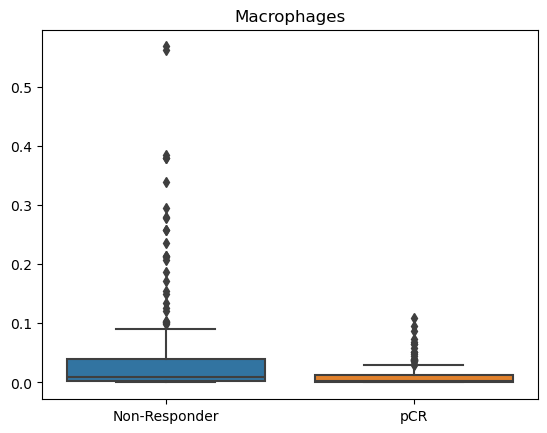

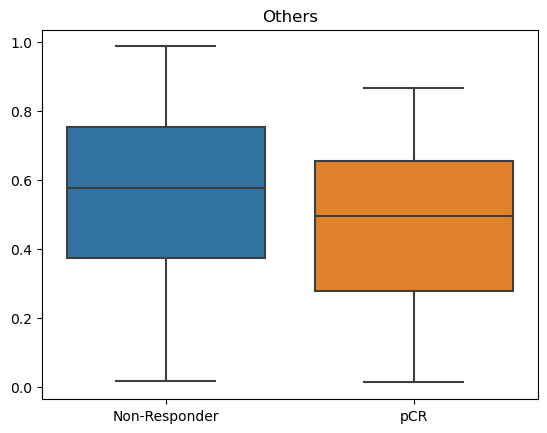

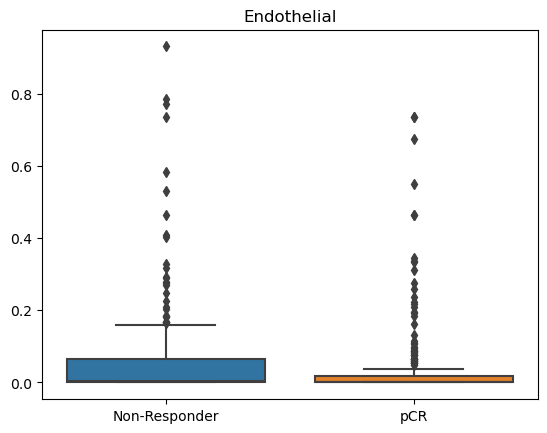

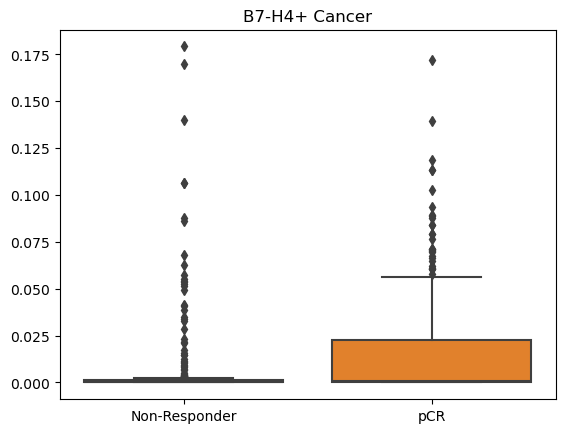

<Figure size 640x480 with 0 Axes>

In [187]:
#for protein in sc.get.rank_genes_groups_df(cell_type_per_fov, group='Non-Responder', key='wilcoxon').names.iloc[0:3]:
for protein in stat_sign_diff_ct:
    a= cell_type_per_fov[:,cell_type_per_fov.var.index == protein]
    a = pd.DataFrame([np.squeeze(a[a.obs.Response=='Non-Responder'].X),np.squeeze(a[a.obs.Response=='pCR'].X)],index = ['Non-Responder','pCR']).T
    sns.boxplot(a)
    plt.title(protein)
    #plt.ylim(0,0.5)
    plt.figure()

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


[<Axes: title={'center': 'Non-Responder vs. pCR'}, xlabel='genes', ylabel='expression'>]

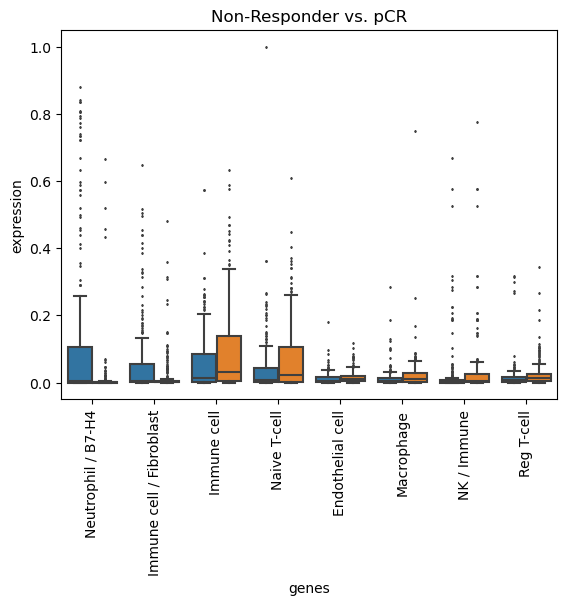

In [28]:
from typing import Union, Optional, List, Sequence, Iterable, Mapping, Literal
from matplotlib.axes import Axes
from anndata import AnnData
def rank_genes_groups_box(
    adata: AnnData,
    groups: Optional[Sequence[str]] = None,
    n_genes: int = 20,
    gene_names: Optional[Iterable[str]] = None,
    gene_symbols: Optional[str] = None,
    use_raw: Optional[bool] = None,
    key: Optional[str] = None,
    split: bool = True,
    scale: str = 'width',
    strip: bool = True,
    jitter: Union[int, float, bool] = True,
    size: int = 1,
    ax: Optional[Axes] = None,
    show: Optional[bool] = None,
    save: Optional[bool] = None,
):
    """\
    Plot ranking of genes for all tested comparisons.

    Parameters
    ----------
    adata
        Annotated data matrix.
    groups
        List of group names.
    n_genes
        Number of genes to show. Is ignored if `gene_names` is passed.
    gene_names
        List of genes to plot. Is only useful if interested in a custom gene list,
        which is not the result of :func:`scanpy.tl.rank_genes_groups`.
    gene_symbols
        Key for field in `.var` that stores gene symbols if you do not want to
        use `.var_names` displayed in the plot.
    use_raw
        Use `raw` attribute of `adata` if present. Defaults to the value that
        was used in :func:`~scanpy.tl.rank_genes_groups`.
    split
        Whether to split the violins or not.
    scale
        See :func:`~seaborn.violinplot`.
    strip
        Show a strip plot on top of the violin plot.
    jitter
        If set to 0, no points are drawn. See :func:`~seaborn.stripplot`.
    size
        Size of the jitter points.
    {show_save_ax}
    """
    if key is None:
        key = 'rank_genes_groups'
    groups_key = str(adata.uns[key]['params']['groupby'])
    if use_raw is None:
        use_raw = bool(adata.uns[key]['params']['use_raw'])
    reference = str(adata.uns[key]['params']['reference'])
    groups_names = adata.uns[key]['names'].dtype.names if groups is None else groups
    if isinstance(groups_names, str):
        groups_names = [groups_names]
    axs = []
    for group_name in groups_names:
        if gene_names is None:
            _gene_names = adata.uns[key]['names'][group_name][:n_genes]
        else:
            _gene_names = gene_names
        if isinstance(_gene_names, np.ndarray):
            _gene_names = _gene_names.tolist()
        df = sc.plotting._tools.obs_df(adata, _gene_names, use_raw=use_raw, gene_symbols=gene_symbols)
        new_gene_names = df.columns
        df['hue'] = adata.obs[groups_key].astype(str).values
        if reference == 'rest':
            df.loc[df['hue'] != group_name, 'hue'] = 'rest'
        else:
            df.loc[~df['hue'].isin([group_name, reference]), 'hue'] = np.nan
        df['hue'] = df['hue'].astype('category')
        df_tidy = pd.melt(df, id_vars='hue', value_vars=new_gene_names)
        x = 'variable'
        y = 'value'
        hue_order = [group_name, reference]
        import seaborn as sns

        _ax = sns.boxplot(
            x=x,
            y=y,
            data=df_tidy,
            hue_order=hue_order,
            hue='hue',
            fliersize = 1,
            orient='vertical',
            ax=ax,
        )

        _ax.set_xlabel('genes')
        _ax.set_title('{} vs. {}'.format(group_name, reference))
        _ax.legend_.remove()
        _ax.set_ylabel('expression')
        _ax.set_xticklabels(new_gene_names, rotation='vertical')
        writekey = (
            f"rank_genes_groups_"
            f"{adata.uns[key]['params']['groupby']}_"
            f"{group_name}"
        )
        #savefig_or_show(writekey, show=show, save=save)
        axs.append(_ax)
    
    return axs
rank_genes_groups_box(cell_type_per_fov, gene_names= stat_sign_diff_ct,key="wilcoxon",show = False)

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


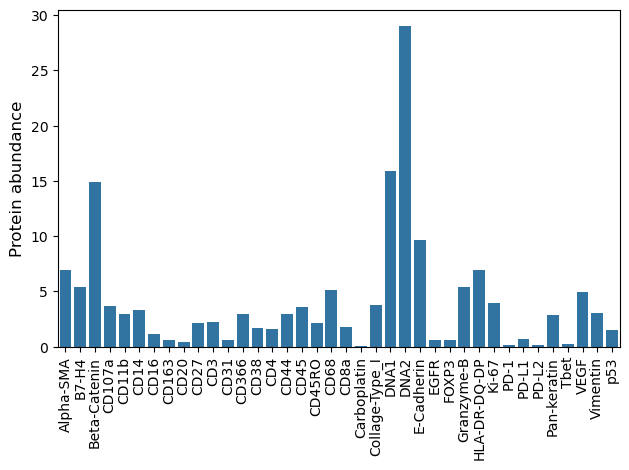

In [188]:
sns.barplot(x = core.var.index,y = core[core.obs.Pixie=='B7-H4+ Cancer'].X.mean(axis = 0),color='C0')
_ = plt.xticks(rotation=90,fontsize = 10)
plt.ylabel('Protein abundance',fontsize = 12)
plt.tight_layout()
#plt.savefig(output_fig+'/diff_expr_marker/CD11_MAC_prot')

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


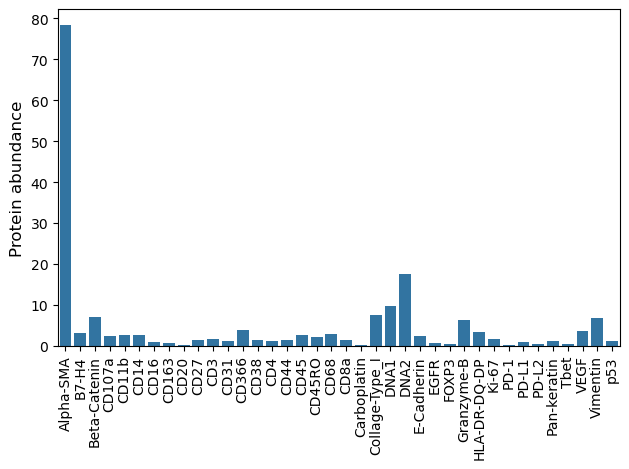

In [4]:
sns.barplot(x = core.var.index,y = core[core.obs.Pixie=='Fibroblasts + collagen'].X.mean(axis = 0),color='C0')
_ = plt.xticks(rotation=90,fontsize = 10)
plt.ylabel('Protein abundance',fontsize = 12)
plt.tight_layout()
#plt.savefig(output_fig+'/diff_expr_marker/CD11_MAC_prot')

In [30]:
def grouped_obs_mean(adata, group_key, layer=None, gene_symbols=None):
    '''
    groups cells by group_key and returns the mean
    '''
    if layer is not None:
        getX = lambda x: x.layers[layer]
    else:
        getX = lambda x: x.X
    if gene_symbols is not None:
        new_idx = adata.var[idx]
    else:
        new_idx = adata.var_names

    grouped = adata.obs.groupby(group_key)
    out = pd.DataFrame(
        np.zeros((adata.shape[1], len(grouped)), dtype=np.float64),
        columns=list(grouped.groups.keys()),
        index=adata.var_names
    )

    for group, idx in grouped.indices.items():
        X = getX(adata[idx])
        out[group] = np.ravel(X.mean(axis=0, dtype=np.float64))
    return out
    

In [31]:
mean_expr = sc.AnnData(grouped_obs_mean(adata,'Leap_ID').T)


In [32]:
#mean_expr.obs.reset_index(names = ['Leap_ID'],inplace=True)
mean_expr.obs
mean_expr.obs = pd.merge(left = mean_expr.obs,right = adata.obs.drop_duplicates('Leap_ID'),left_index=True, right_on='Leap_ID',how='left')

Now run the analysis https://nbisweden.github.io/workshop-scRNAseq/labs/compiled/scanpy/scanpy_05_dge.html

In [33]:
core = mean_expr[mean_expr.obs['SAMPLE_TYPE_(CORE/RESECTION)']=='CORE'].copy()

## T-test

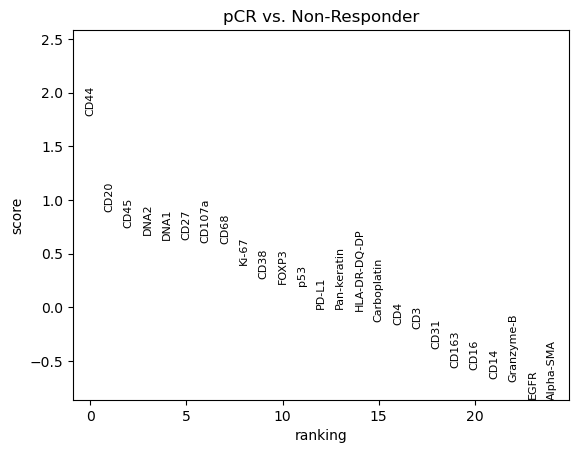

In [34]:

sc.tl.rank_genes_groups(core, groupby='Response',groups=['pCR'],reference='Non-Responder', method='t-test', key_added = "t-test")
sc.pl.rank_genes_groups(core, n_genes=25, sharey=False, key = "t-test")

In [51]:
sc.pl.rank_genes_groups?

## T-test overexpression

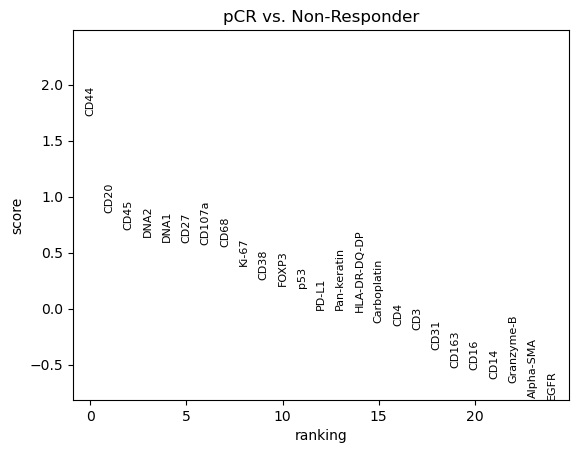

In [35]:
sc.tl.rank_genes_groups(core, groupby='Response', method='t-test_overestim_var',groups=['pCR'],reference='Non-Responder', key_added = "t-test_ov")
sc.pl.rank_genes_groups(core, n_genes=25, sharey=False, key = "t-test_ov")

In [40]:
core.uns['wilcoxon']['names']['pCR']
core.uns['wilcoxon']['pvals_adj']['pCR']

array([0.78574766, 0.78574766, 0.78574766, 0.78574766, 0.79670538,
       0.79670538, 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 0.81131073, 0.79670538,
       0.79670538, 0.78574766, 0.78574766, 0.78574766, 0.78574766,
       0.78574766, 0.78574766, 0.78574766, 0.78574766, 0.78574766,
       0.78574766, 0.36599567, 0.36599567])

## wilcoxon

Statistically significant differentially expressed markers are:



/home/giuseppe/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/tmp/ipykernel_200202/760792561.py:3: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


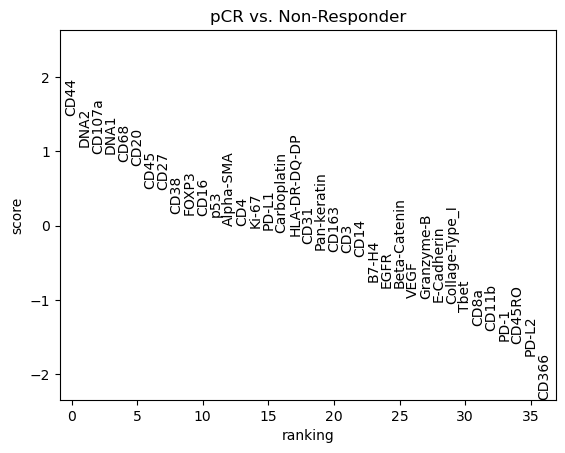

In [41]:

sc.tl.rank_genes_groups(core, groupby='Response',  method='wilcoxon',groups=['pCR'],reference='Non-Responder', key_added = "wilcoxon")
sc.pl.rank_genes_groups(core, n_genes=37, sharey=False, key = "wilcoxon",fontsize=10,show = False)
plt.tight_layout()
#plt.savefig('figures/diff_expr_marker/rank_genes.png')
print('Statistically significant differentially expressed markers are:')
print(*core.uns['wilcoxon']['names']['pCR'][core.uns['wilcoxon']['pvals_adj']['pCR']<0.01],sep = ',')

/home/giuseppe/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


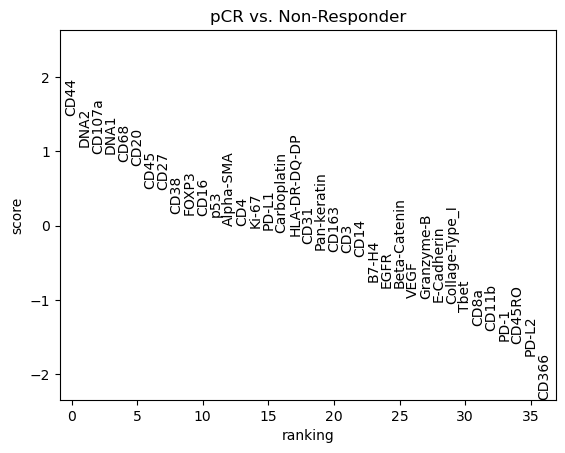

In [42]:
sc.tl.rank_genes_groups(core, groupby='Response',  method='wilcoxon',groups=['pCR'],reference='Non-Responder', key_added = "wilcoxon")
sc.pl.rank_genes_groups(core, n_genes=37, sharey=False, key = "wilcoxon",fontsize=10,show = False)


In [43]:
sc.get.rank_genes_groups_df(core, group='pCR', key='wilcoxon')

,names,scores,logfoldchanges,pvals,pvals_adj
0,CD44,1.483354,0.494156,0.137980,0.785748
1,DNA2,1.054830,0.166601,0.291503,0.785748
2,CD107a,0.972421,0.132515,0.330841,0.785748
3,DNA1,0.972421,0.147280,0.330841,0.785748
4,CD68,0.857049,0.147240,0.391418,0.796705
5,CD20,0.807604,0.370112,0.419319,0.796705
6,CD45,0.494451,0.223429,0.620987,1.000000
7,CD27,0.477970,0.207724,0.632672,1.000000
8,CD38,0.164817,0.069658,0.869088,1.000000
9,FOXP3,0.148335,0.042234,0.882078,1.000000


/home/giuseppe/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


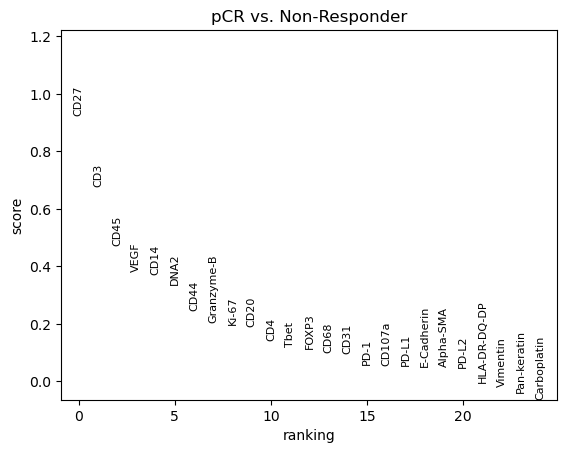

In [146]:

sc.tl.rank_genes_groups(core, groupby='Response', method='logreg',groups=['pCR'],reference='Non-Responder',key_added = "logreg")
sc.pl.rank_genes_groups(core, n_genes=25, sharey=False, key = "logreg")


/home/giuseppe/anaconda3/lib/python3.9/site-packages/matplotlib_venn/_venn3.py:47: UserWarning: All circles have zero area
  warnings.warn("All circles have zero area")


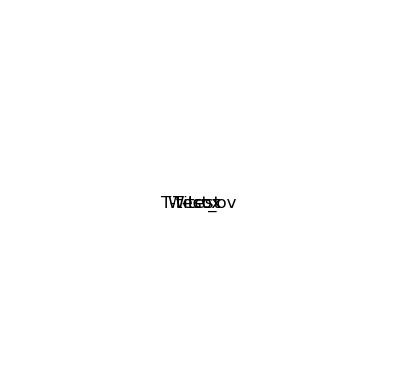

In [150]:
sc.get.rank_genes_groups_df(core, group='pCR', key='wilcoxon')
wc = sc.get.rank_genes_groups_df(core, group='pCR', key='wilcoxon', pval_cutoff=0.01)['names']
tt = sc.get.rank_genes_groups_df(core, group='pCR', key='t-test', pval_cutoff=0.01)['names']
tt_ov = sc.get.rank_genes_groups_df(core, group='pCR', key='t-test_ov', pval_cutoff=0.01)['names']

from matplotlib_venn import venn3

venn3([set(wc),set(tt),set(tt_ov)], ('Wilcox','T-test','T-test_ov') )
plt.show()

In [152]:
core.uns.keys()
sc.get.rank_genes_groups_df(core, group='pCR', key='wilcoxon')

,names,scores,logfoldchanges,pvals,pvals_adj
0,CD44,1.227888,1.059972,0.219489,0.856249
1,CD107a,0.964180,0.006420,0.334956,0.856249
2,CD20,0.848808,1.061273,0.395988,0.856249
3,DNA2,0.832326,2.548695,0.405225,0.856249
4,DNA1,0.683991,1.209897,0.493981,0.856249
5,CD68,0.618064,0.499396,0.536533,0.856249
6,CD27,0.618064,0.430699,0.536533,0.856249
7,CD45,0.535656,0.842340,0.592197,0.856249
8,FOXP3,0.238985,0.039710,0.811117,0.948759
9,CD4,0.041204,0.038025,0.967133,0.967133


In [166]:
core.obs.columns

Index(['Pixie', 'acquisition_ID', 'Leap_ID', 'SLIDE_NUMBER', 'BIOBANK_ID',
       'SAMPLE_TYPE_(CORE/RESECTION)', 'FORMAT_(FFPE/FROZEN)',
       'FORCE_TRIAL?_(Y/N)', 'DATE_SECTIONED', 'H&E_NOTES', 'ST_NOTES',
       'Response', 'COMMENTS', 'note_if_frozen_(otherwise_FFPE)',
       'Extreme_non-responder_(death_within_2_years?)'],
      dtype='object')

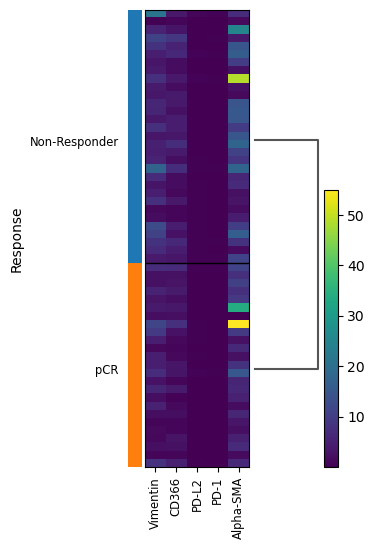

In [170]:
genes_high_pvalue = sc.get.rank_genes_groups_df(core, group='pCR', key='wilcoxon').sort_values('pvals')['names'].iloc[:5].values
sc.pl.rank_genes_groups_heatmap(core,var_names=genes_high_pvalue, key="wilcoxon", groupby="Response")


/home/giuseppe/anaconda3/lib/python3.9/site-packages/scanpy/plotting/_matrixplot.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  values_df = self.obs_tidy.groupby(level=0).mean()


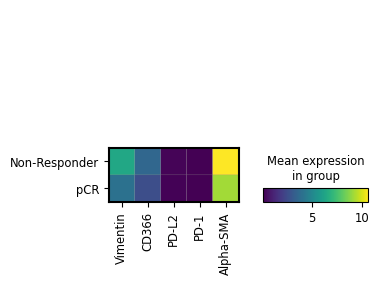

In [171]:
sc.pl.rank_genes_groups_matrixplot(core,  key="wilcoxon", groupby="Response",var_names = genes_high_pvalue)

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Categorica

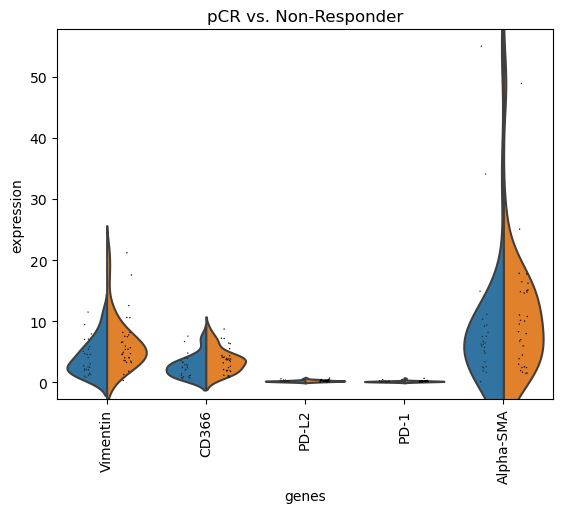

<Figure size 640x480 with 0 Axes>

In [161]:
sc.pl.rank_genes_groups_violin(core,key = 'wilcoxon',gene_names = genes_high_pvalue)
plt.tight_layout()

In [507]:
!mkdir figures/diff_expr_marker

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/tmp/ipykernel_46304/934443878.py:6: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/tmp/ipykernel_46304/934443878.py:6: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/tmp/ipykernel_46304/934443878.py:6: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.

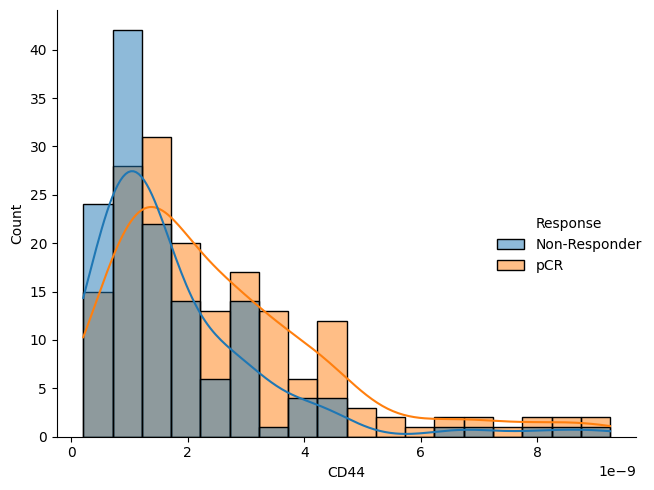

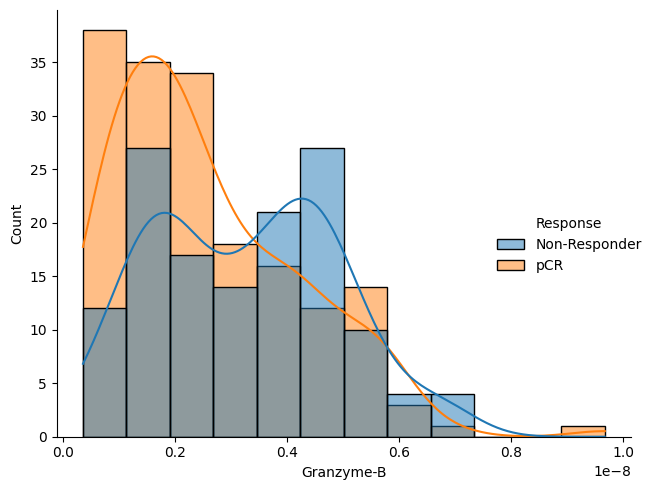

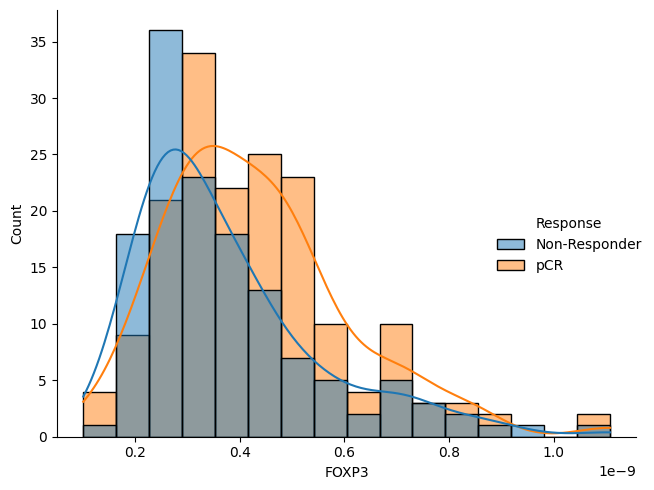

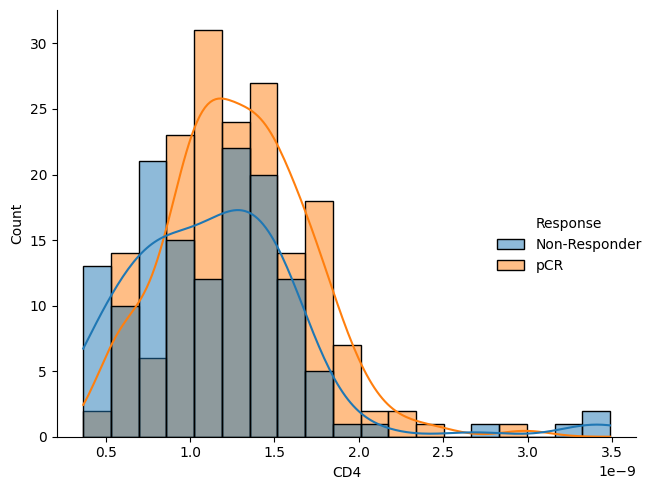

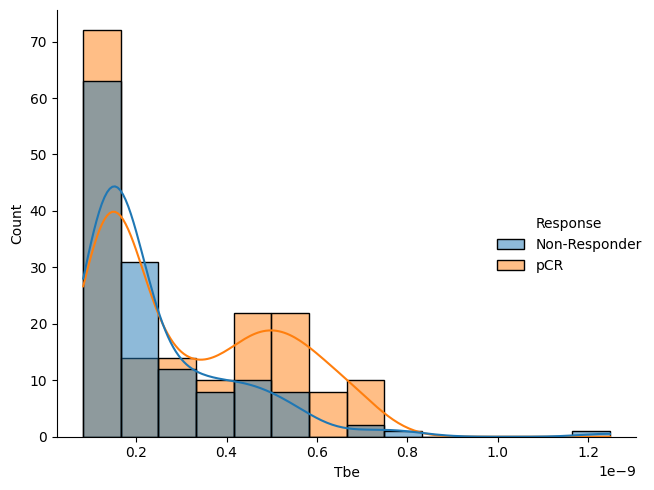

In [508]:
for gene in genes_high_pvalue:
    a = np.ravel(core[:,core.var.index==gene].X[:])
    b = core[:,core.var.index==gene].obs.Response.values
    a = pd.DataFrame(np.vstack((a,b)).T,columns=['expression','Response'])
    sns.displot(data = a,x = 'expression',hue='Response',kde = True)
    plt.tight_layout()
    plt.savefig('figures/diff_expr_marker/'+gene+'.png')
    plt.xlabel(gene)

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


<Axes: xlabel='CD44', ylabel='Density'>

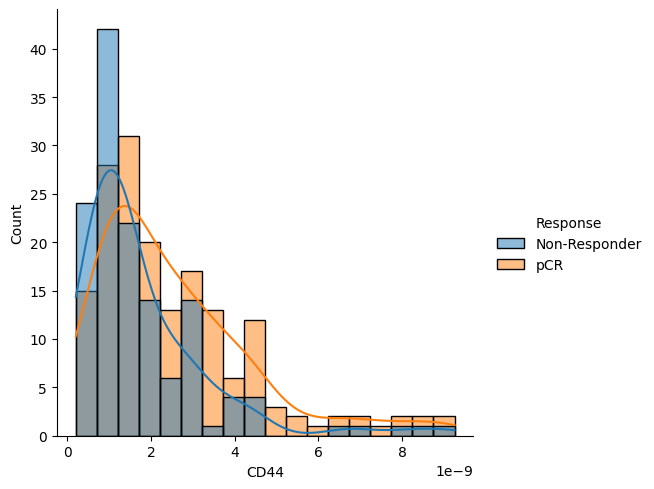

In [457]:
a = np.ravel(core[:,core.var.index=='CD44'].X[:])
b = core[:,core.var.index=='CD44'].obs.Response.values
a = pd.DataFrame(np.vstack((a,b)).T,columns=['expression','Response'])
sns.displot(data = a,x = 'expression',hue='Response',kde = True)

plt.xlabel('CD44')
ax

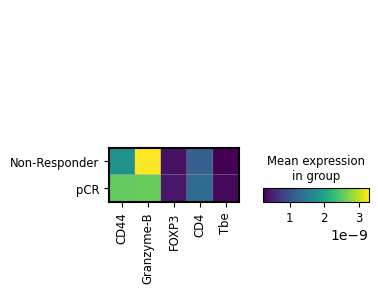

In [460]:
#sc.pl.rank_genes_groups_dotplot(core, n_genes=5, key="wilcoxon", groupby="Response")


/home/giuseppe/anaconda3/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


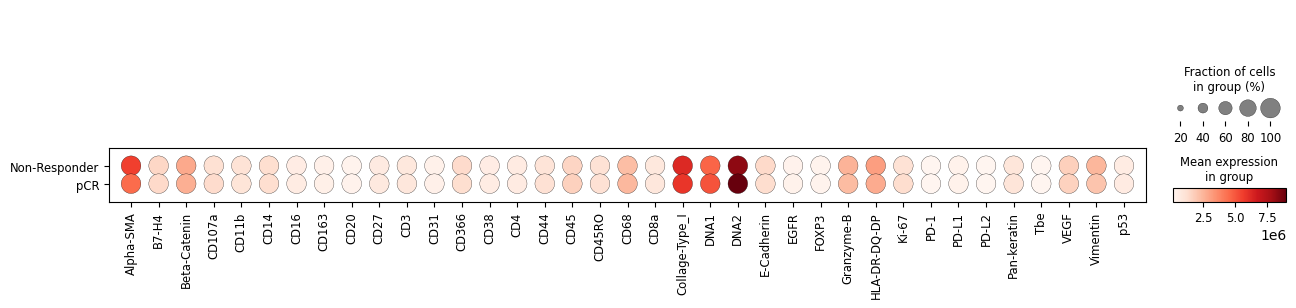

In [551]:
sc.pl.dotplot(adata,adata.var_names, groupby='Response')

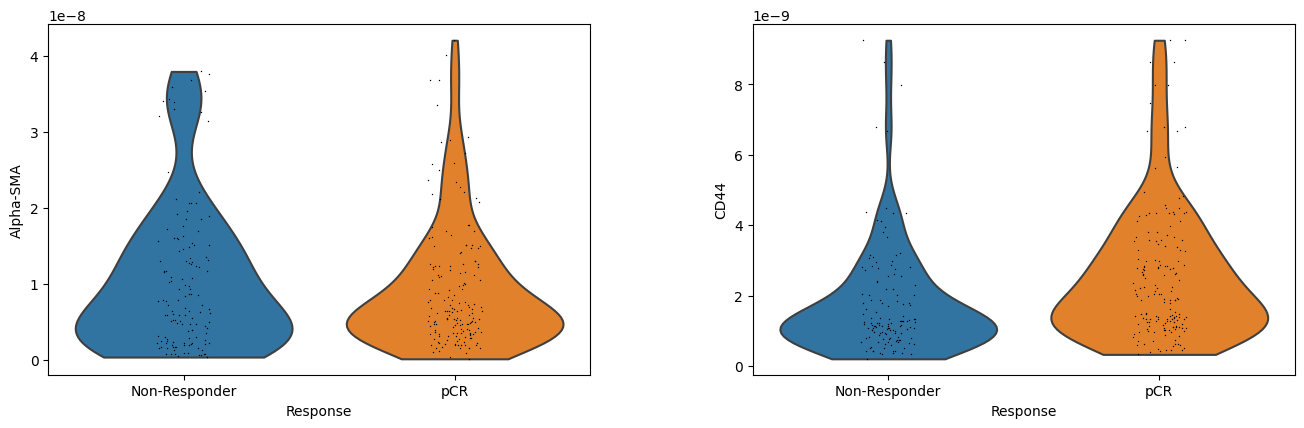

In [466]:
sc.pl.violin(core,['Alpha-SMA','CD44'], groupby='Response')


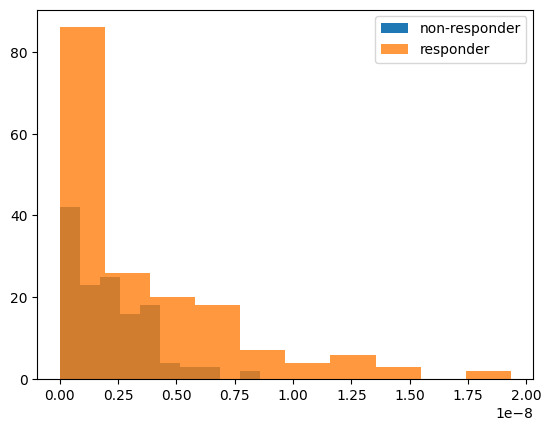

In [250]:
#sns.histplot()
x = core[:,core.var.index == 'CD44']
plt.hist(x[x.obs.Response == 'Non-Responder'].X,label = 'non-responder')
plt.hist(x[x.obs.Response == 'pCR'].X,alpha = 0.8,label = 'responder')
plt.legend()

(array([89., 27., 18., 17.,  7.,  6.,  2.,  2.,  2.,  2.]),
 array([8.63226596e-12, 6.92759639e-09, 1.38465605e-08, 2.07655246e-08,
        2.76844887e-08, 3.46034529e-08, 4.15224170e-08, 4.84413811e-08,
        5.53603452e-08, 6.22793093e-08, 6.91982735e-08]),
 <BarContainer object of 10 artists>)

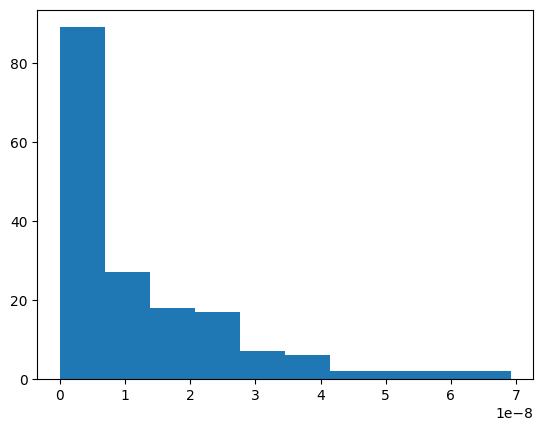

In [205]:
plt.hist(x[x.obs.Response == 'pCR'].X)

/home/giuseppe/anaconda3/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


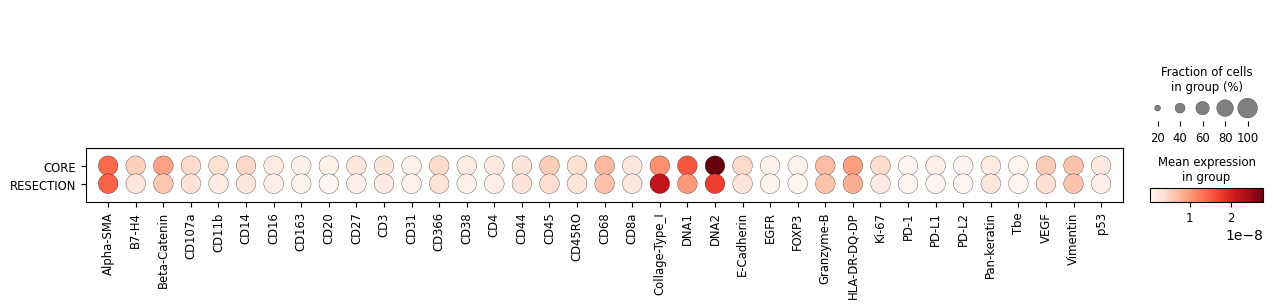

In [40]:
sc.pl.dotplot(adata,adata.var_names, groupby='SAMPLE_TYPE_(CORE/RESECTION)')

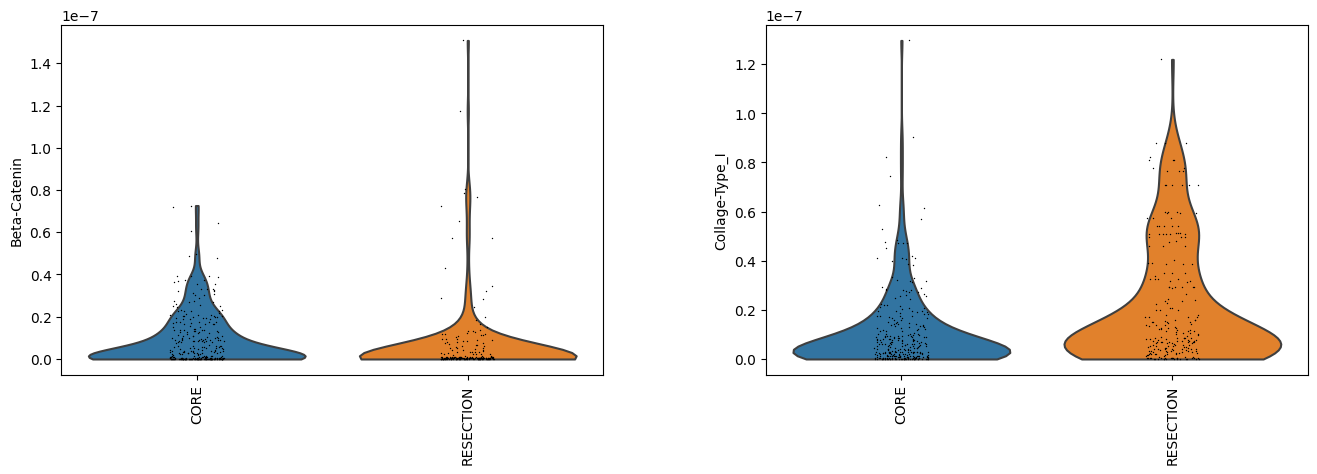

In [43]:
sc.pl.violin(adata,['Beta-Catenin','Collage-Type_I'], groupby='SAMPLE_TYPE_(CORE/RESECTION)', rotation=90)

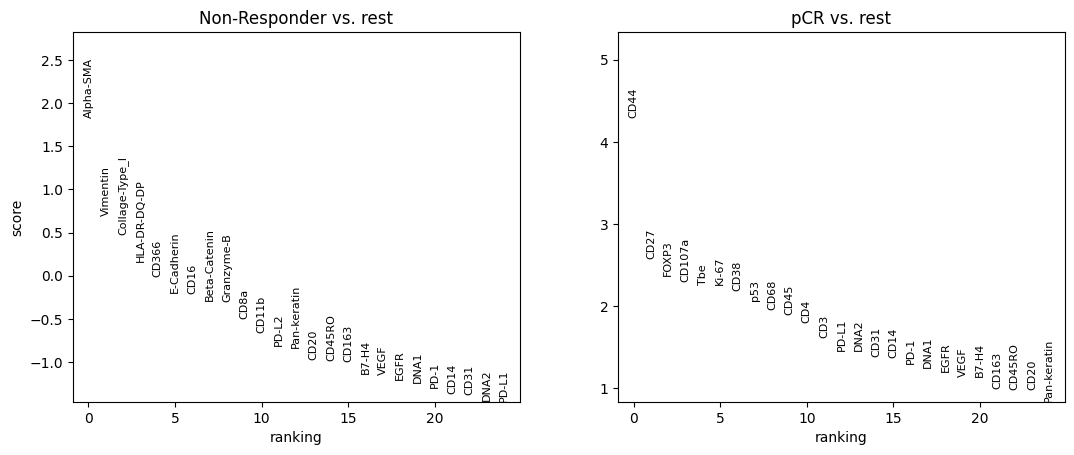

In [64]:
core = adata[adata.obs['SAMPLE_TYPE_(CORE/RESECTION)']=='CORE'].copy()
sc.tl.rank_genes_groups(core, groupby='Response', method='t-test', key_added = "t-test")
sc.pl.rank_genes_groups(core, n_genes=25, sharey=False, key = "t-test")

In [ ]:
core = mean_expr[mean_expr.obs['SAMPLE_TYPE_(CORE/RESECTION)']=='CORE'].copy()

In [113]:
#LU
genes_high_pvalue = sc.get.rank_genes_groups_df(core, group='Non-Responder', key='wilcoxon').sort_values('pvals')['names'].iloc[:38].values
sc.pl.rank_genes_groups_heatmap(core,var_names=genes_high_pvalue, key="wilcoxon", groupby="Response")


KeyError: 'wilcoxon'

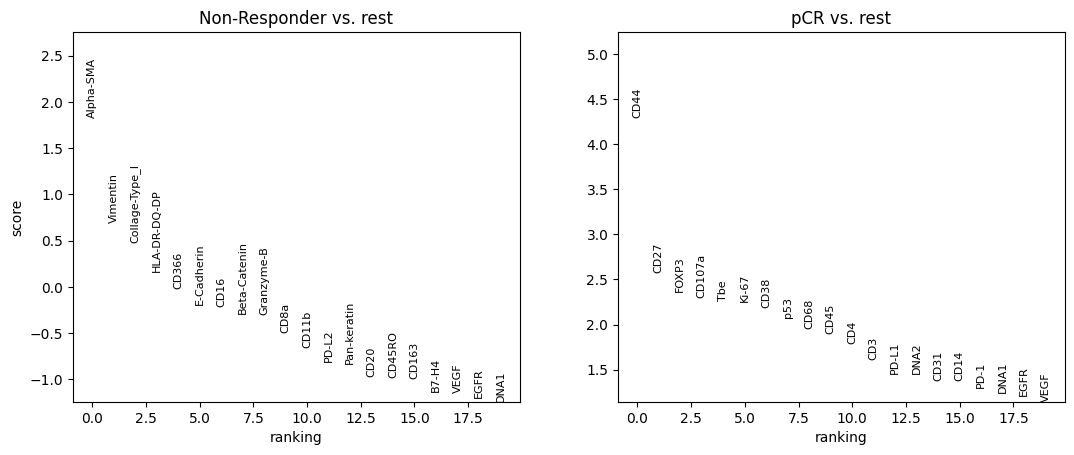

In [66]:
sc.tl.rank_genes_groups(adata, 'louvain_0.6', method='t-test_overestim_var', key_added = "t-test_ov")
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False, key = "t-test_ov")

In [ ]:
sc.tl.rank_genes_groups(adata, groupby='Response', method='t-test', key_added = "t-test")
#sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False, key = "t-test")

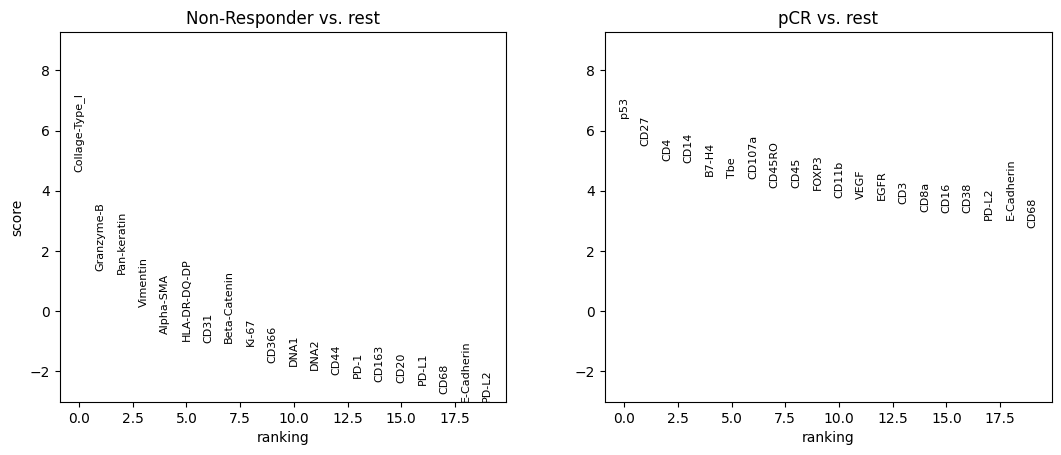

In [71]:
sc.tl.rank_genes_groups(core, groupby='Response', method='wilcoxon')
sc.pl.rank_genes_groups(adata)

<Axes: >

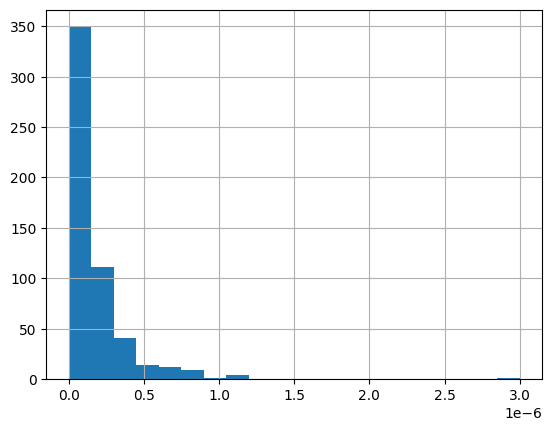

In [70]:
tot_intensity.sum(axis = 1).hist(bins = 20)

## Carboplatin

In [117]:
resection = adata[adata.obs['SAMPLE_TYPE_(CORE/RESECTION)']=='RESECTION']

In [89]:
dic ={}
for key, indices in resection.obs.groupby('Pixie').groups.items():
    dic[key] = np.squeeze(resection[indices,resection.var.index == 'Carboplatin'].X)


/tmp/ipykernel_200202/4102534511.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for key, indices in resection.obs.groupby('Pixie').groups.items():


/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Categorica

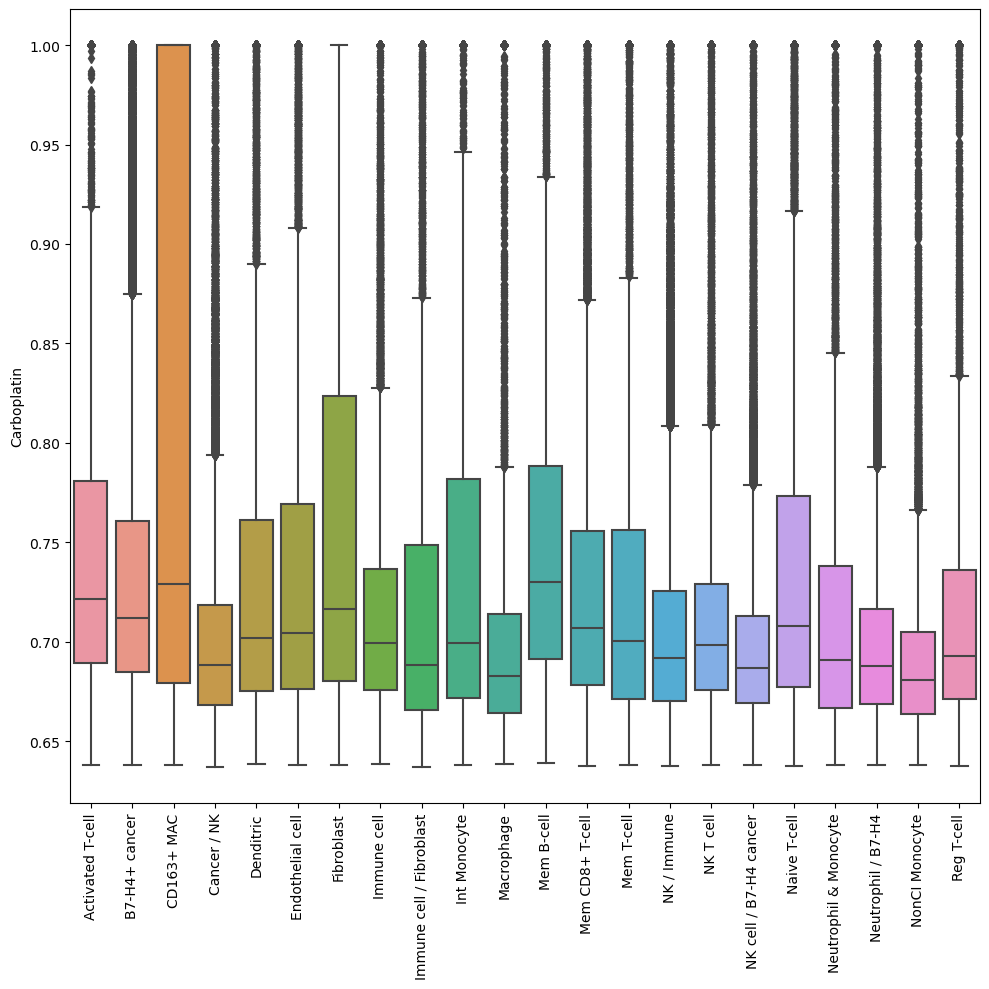

In [128]:
a = pd.DataFrame({k:np.quantile(v,q=[0.25,0.5,0.75]) for k,v in dic.items()},index=  [0.25,0.5,0.75])
plt.figure(figsize =(10,10))
box = sns.boxplot(pd.DataFrame.from_dict(dic,orient = 'index').T)
plt.gca().tick_params(axis='x', labelrotation=90)
f = box.get_figure()
plt.ylabel('Carboplatin')
plt.tight_layout()
#plt.savefig('../figures/carboplatin_cell_type.png')


In [118]:
a

,Activated T-cell,B7-H4+ cancer,CD163+ MAC,Cancer / NK,Denditric,Endothelial cell,Fibroblast,Immune cell,Immune cell / Fibroblast,Int Monocyte,...,Mem CD8+ T-cell,Mem T-cell,NK / Immune,NK T cell,NK cell / B7-H4 cancer,Naive T-cell,Neutrophil & Monocyte,Neutrophil / B7-H4,NonCI Monocyte,Reg T-cell
0.25,0.689421,0.684610,0.679260,0.668443,0.675458,0.676493,0.680319,0.675686,0.665748,0.671726,...,0.678210,0.671187,0.670059,0.675838,0.669064,0.677450,0.666931,0.668778,0.663792,0.671179
0.50,0.721309,0.712201,0.729013,0.688444,0.701722,0.704177,0.716517,0.699281,0.688298,0.699308,...,0.706748,0.700400,0.691985,0.698203,0.687032,0.707981,0.691050,0.687803,0.680887,0.692654
0.75,0.781054,0.760669,1.000000,0.718638,0.761299,0.769151,0.823364,0.736552,0.748722,0.781751,...,0.755684,0.755997,0.725376,0.729097,0.713027,0.773090,0.738336,0.716367,0.704773,0.736174


In [ ]:
dp=sc.pl.dotplot(adata, ['CD79A', 'MS4A1'], 'bulk_labels', show=False)
# All Axes used in dotplot
print('Dotplot axes:',dp)
# Select the Axes object that contains the subplot of interest
ax=dp['mainplot_ax']
# Loop through ticklabels and make them italic
for l in ax.get_xticklabels():
    l.set_style('italic')
    g=l.get_text()
    # Change settings (e.g. color) of certain ticklabels based on their text (here gene name)
    if g =='MS4A1':
        l.set_color('#A97F03')